# Plotting: Number of Training Samples per Class

In [178]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
import json

In [179]:
dataset = "aitv2"
scenario = "santos"

logic_files = [
    "ait_logic", 
    "ait_flags",
]

baseline_models = [
    "multiclass",
    "ensemble",
]

In [180]:
subsets = [
    "5b5a", 
    "10b10a", 
    "20b20a", 
    "30b30a", 
    "50b50a", 
    "100b100a", 
    "500b500a", 
    "1000b1000a", 
    "5000b5000a", 
    "10000b10000a"
]

In [181]:
experiments = {}

for logic_file in logic_files:
    metrics_dir = Path(f"../experiments/{dataset}/{scenario}/deepproblog/{logic_file}/metrics")
    file_paths = list(metrics_dir.iterdir())

    f1_scores = {}
    false_positives = {}
    detection_rates = {}

    for file_path in file_paths:
        experiment_name = str(file_path.stem)
        experiment_name_parts = experiment_name.split("_")

        subset = experiment_name_parts[-3]
        if subset not in subsets:
            continue

        if "pretrained" in experiment_name:
            continue

        if "aug" not in experiment_name:
            continue

        model_name = f"dpl_{logic_file}_end_to_end"


        # print(f"Processing {experiment_name}...")
        data = np.load(file_path, allow_pickle=True)
        metrics = data["metrics"].item()
        # print(metrics)
        subset_size = int(subset.split("b")[0])
        f1_scores[subset_size] = metrics["macro_f1"]
        false_positives[subset_size] = metrics["false_alarm_rate"]
        detection_rates[subset_size] = metrics["detection_rate"]



    scores_zip = zip(f1_scores.keys(), f1_scores.values(), false_positives.values(), detection_rates.values())
    scores_sorted = sorted(scores_zip, key=lambda x: x[0])

    experiments[model_name] = {
        "subset_sizes": [item[0] for item in scores_sorted],
        "f1_scores": [item[1] for item in scores_sorted], 
        "false_positive_rates": [item[2] for item in scores_sorted],
        "detection_rates": [item[3] for item in scores_sorted]
    }


In [182]:
for logic_file in logic_files:
    metrics_dir = Path(f"../experiments/{dataset}/{scenario}/deepproblog/{logic_file}/metrics")
    file_paths = list(metrics_dir.iterdir())

    f1_scores = {}
    false_positives = {}
    detection_rates = {}

    for file_path in file_paths:
        experiment_name = str(file_path.stem)
        experiment_name_parts = experiment_name.split("_")

        subset = experiment_name_parts[-3]
        if subset not in subsets:
            continue

        if "pretrained" not in experiment_name:
            continue

        if "aug" not in experiment_name:
            continue

        model_name = f"dpl_{logic_file}_pretrained"


        # print(f"Processing {experiment_name}...")
        data = np.load(file_path, allow_pickle=True)
        metrics = data["metrics"].item()
        # print(metrics)
        subset_size = int(subset.split("b")[0])
        f1_scores[subset_size] = metrics["macro_f1"]
        false_positives[subset_size] = metrics["false_alarm_rate"]
        detection_rates[subset_size] = metrics["detection_rate"]



    scores_zip = zip(f1_scores.keys(), f1_scores.values(), false_positives.values(), detection_rates.values())
    scores_sorted = sorted(scores_zip, key=lambda x: x[0])

    experiments[model_name] = {
        "subset_sizes": [item[0] for item in scores_sorted],
        "f1_scores": [item[1] for item in scores_sorted], 
        "false_positive_rates": [item[2] for item in scores_sorted],
        "detection_rates": [item[3] for item in scores_sorted]
    }


In [183]:
for model in baseline_models:
    model_name = f"baseline_{model}"
    metrics_dir = Path(f"../experiments/{dataset}/{scenario}/baselines/{model}/metrics")
    file_paths = list(metrics_dir.iterdir())

    f1_scores = {}
    false_positives = {}
    detection_rates = {}

    for file_path in file_paths:
        experiment_name = str(file_path.stem)
        experiment_name_parts = experiment_name.split("_")

        subset = experiment_name_parts[-1]
        if subset not in subsets:
            continue

        if "aug" not in experiment_name:
            continue
        
        # print(f"Processing {experiment_name}...")
        with open(file_path) as f:
            metrics = json.load(f)
        # print(metrics)
        
        subset_size = int(subset.split("b")[0])
        f1_scores[subset_size] = metrics["Macro F1"]
        false_positives[subset_size] = metrics["False Alarm Rate"]
        detection_rates[subset_size] = metrics["Detection Rate"]

    scores_zip = zip(f1_scores.keys(), f1_scores.values(), false_positives.values(), detection_rates.values())
    scores_sorted = sorted(scores_zip, key=lambda x: x[0])

    experiments[model_name] = {
        "subset_sizes": [item[0] for item in scores_sorted],
        "f1_scores": [item[1] for item in scores_sorted], 
        "false_positive_rates": [item[2] for item in scores_sorted],
        "detection_rates": [item[3] for item in scores_sorted]
    }


In [184]:
experiments

{'dpl_ait_logic_end_to_end': {'subset_sizes': [5,
   10,
   20,
   30,
   50,
   100,
   500,
   1000,
   5000,
   10000],
  'f1_scores': [0.6931144075144006,
   0.6931144075144006,
   0.6931144075144006,
   0.6995287955423592,
   0.6995287955423592,
   0.6931144075144006,
   0.6931144075144006,
   0.6931144075144006,
   0.6931144075144006,
   0.6931144075144006],
  'false_positive_rates': [0.11020945935829678,
   0.11020945935829678,
   0.11020945935829678,
   0.11042306252339948,
   0.11042306252339948,
   0.11020945935829678,
   0.11020945935829678,
   0.11020945935829678,
   0.11020945935829678,
   0.11020945935829678],
  'detection_rates': [1.0,
   1.0,
   1.0,
   0.999866844207723,
   0.999866844207723,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0]},
 'dpl_ait_flags_end_to_end': {'subset_sizes': [5,
   10,
   20,
   30,
   50,
   100,
   500,
   1000,
   5000,
   10000],
  'f1_scores': [0.09226227712693616,
   0.09226227712693616,
   0.09226227712693616,
   0.09226227712693616,
   0.09

In [185]:
def num_samples_plot(experiments, metric, plots_dir, plots_title):
    plt.figure(figsize=(10, 6))
    
    all_subset_sizes = sorted({x for data in experiments.values() for x in data["subset_sizes"]})
    
    for logic_file, data in experiments.items():
        plt.plot(data["subset_sizes"], data[metric], marker='o', label=logic_file)
    
    plt.xscale('log')
    plt.xticks(all_subset_sizes, [str(x) for x in all_subset_sizes])
    plt.xlabel('Number of Training Samples (log scale)')
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f'{plots_title}')
    plt.legend()
    plt.grid(True)
    
    plots_dir.mkdir(parents=True, exist_ok=True)
    plot_path = plots_dir / "num_training_samples.png"
    plt.savefig(plot_path)
    plt.show()
    

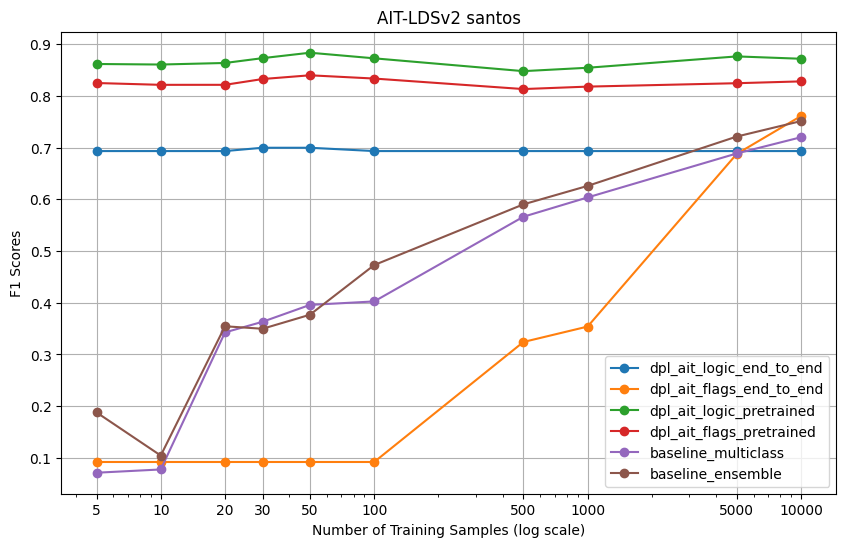

In [186]:
plots_dir = Path(f"../reports/{dataset}/{scenario}")
    
plots_title = f"AIT-LDSv2 {scenario}"
metric = "f1_scores"
num_samples_plot(experiments, metric, plots_dir, plots_title)

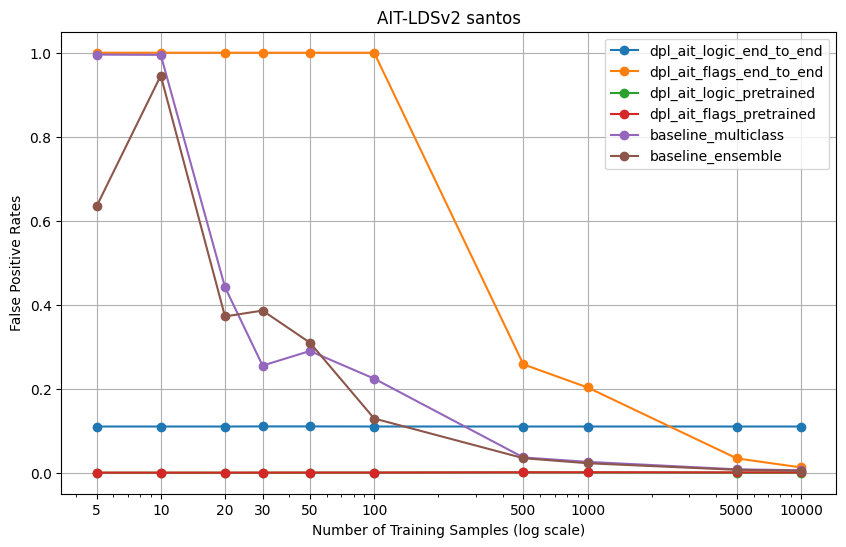

In [187]:
metric = "false_positive_rates"
num_samples_plot(experiments, metric, plots_dir, plots_title)

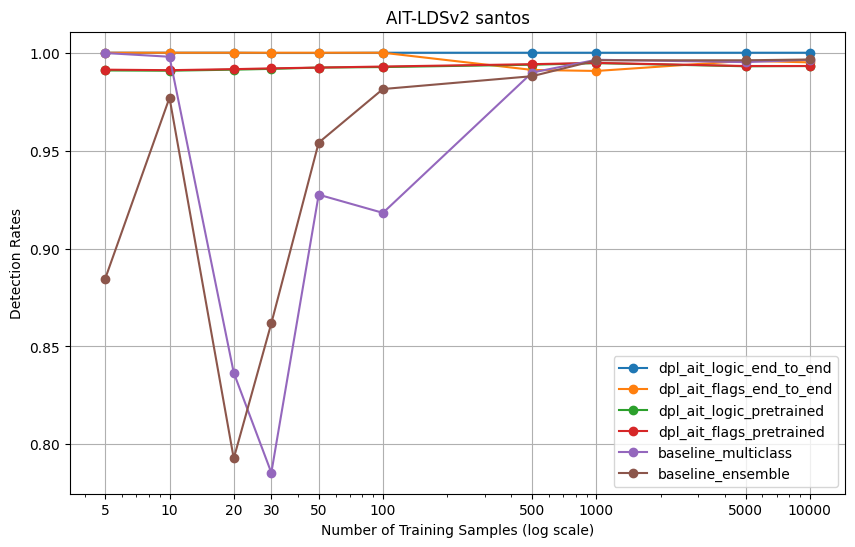

In [188]:
metric = "detection_rates"
num_samples_plot(experiments, metric, plots_dir, plots_title)